In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.gridspec import GridSpec

from fiat_toolbox.well_being import CommunityUnit, WellBeingConfig, CapitalStock, IncomeConfig, SimulationConfig, Liquidity, LossType

In [ ]:
housing_assets = CapitalStock(v=0.7, k=100000)
rental_assets = CapitalStock(v=0.7, k=50000, recovery_time=5)

public_assets = CapitalStock(v=0.4, k=1e-2*5000000, recovery_time=5)
private_assets = CapitalStock(v=0.4, k=1e-2*5000000, recovery_time=4)

income_config = IncomeConfig(i_0=48000, i_avg=48000, pi=0.15, i_div=5000)
sim_config = SimulationConfig(eta=1.5, rho=0.06, t_max=10, dt=1/52, currency="$", c_min=0.0, recovery_per=95.0)
liq = Liquidity(savings=10000)

config = WellBeingConfig(
    owner_housing=housing_assets,
    labour_assets={"Public":public_assets, "Private":private_assets},
    rental_housing=rental_assets,
    income=income_config,
    simulation=sim_config,
    liquidity=liq
    
)

In [3]:
# Create a WellBeing object and optimize the lambda value
household = CommunityUnit(config=config)
household

CommunityUnit(
  owner_housing = k=100000.0 v=0.7 recovery_time=None recovery_rate=None,
  rental_housing = k=50000.0 v=0.7 recovery_time=5.0 recovery_rate=0.599146454710798,
  labour_assets = {'Public': CapitalStock(k=50000.0, v=0.4, recovery_time=5.0, recovery_rate=0.599146454710798), 'Private': CapitalStock(k=50000.0, v=0.4, recovery_time=4.0, recovery_rate=0.7489330683884975)},
  income = i_0=48000.0 i_avg=48000.0 pi=0.15 i_div=0.0,
  liquidity = savings=10000.0 insurance=0.0 support=0.0,
  simulation = eta=1.5 rho=0.06 t_max=10.0 dt=0.019230769230769232 currency='$' c_min=0.0 recovery_per=95.0
)

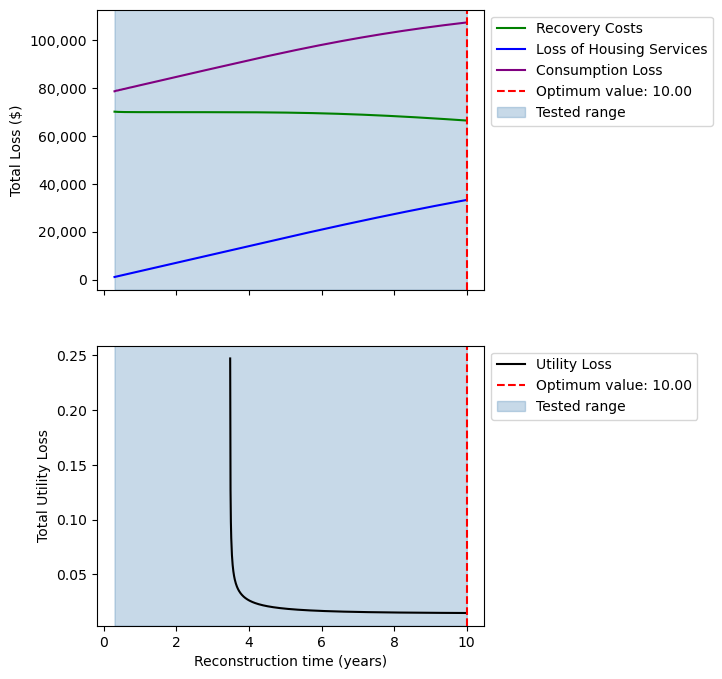

In [4]:
household.opt_lambda(method="trapezoid", eps_rel=0.)
household.plot_opt_lambda(x_type="time");

In [5]:
household.get_losses("trapezoid")

Recovery Costs                        66500.183219
Loss of Housing Services              33297.459759
Loss of Housing Services (Rental)      8740.655432
Labour Income Loss (Public)            4994.660247
Labour Income Loss (Private)           4003.528094
Labour Income Loss                     8998.188340
Consumption Loss                     107536.121724
Utility Loss                              0.014877
Wellbeing Loss                       136254.894704
Asset Loss                            70000.000000
Equity Weighted Loss                  70000.000000
dtype: float64

In [6]:
print(f"Recovery Time: {household.recovery_time:.2f} years")
print(f"Recovery Percentage: {household.recovery_percentage:.2f} %")
print(f"Recovery Time ({household.config.simulation.recovery_per:.2f} %): {household.full_recovery_time:.2f} years")

Recovery Time: 9.79 years
Recovery Percentage: 95.00 %
Recovery Time (95.00 %): 9.79 years


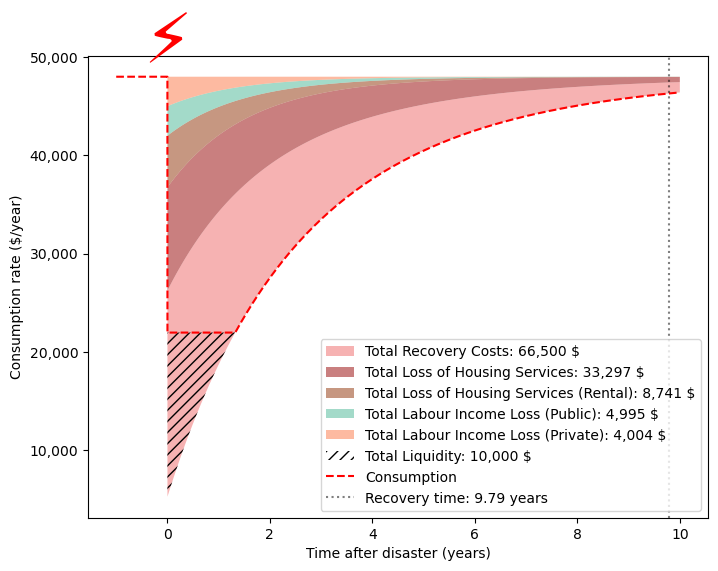

In [7]:
household.plot_consumption()